In [9]:
from pathlib import Path

BASE = Path("/Users/macbookpro14m1pro/Desktop/RagTable/data/pubtabnet-1M")
ds1_img  = BASE / "table_segmentation_1/data/images"
ds1_mask = BASE / "table_segmentation_1/data/masks"
ds2_mask = BASE / "table_segmentation_2/data/masks"
ds3_mask = BASE / "table_segmentation_3/data/masks"

# Gom tất cả IDs có mask
all_mask_ids = set()
for mask_dir in [ds1_mask, ds2_mask, ds3_mask]:
    for f in mask_dir.glob("*_row.png"):
        all_mask_ids.add(f.stem.replace("_row", ""))

# IDs có image
all_img_ids = set(f.stem for f in ds1_img.glob("*.png"))

print(f"Total mask IDs: {len(all_mask_ids):,}")
print(f"Total image IDs: {len(all_img_ids):,}")
print(f"IDs có cả image lẫn mask: {len(all_mask_ids & all_img_ids):,}")
print(f"IDs có mask nhưng không có image: {len(all_mask_ids - all_img_ids):,}")
print(f"IDs có image nhưng không có mask: {len(all_img_ids - all_mask_ids):,}")

Total mask IDs: 30,000
Total image IDs: 30,000
IDs có cả image lẫn mask: 30,000
IDs có mask nhưng không có image: 0
IDs có image nhưng không có mask: 0


In [10]:
# ── Imports ───────────────────────────────────────────────
import torch
import random
import numpy as np
from PIL import Image
from pathlib import Path
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF

# ── Config ────────────────────────────────────────────────
BATCH_SIZE = 8
IMG_SIZE = 384
device     = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ── Đường dẫn ─────────────────────────────────────────────
BASE = Path("/Users/macbookpro14m1pro/Desktop/RagTable/data/pubtabnet-1M")

IMG_DIR = BASE / "table_segmentation_1/data/images"

MASK_DIR_DILATED = BASE / "masks_dilated"

# Build lookup: sid → mask_dir
mask_dir_lookup = {}
for f in MASK_DIR_DILATED.glob("*_row.png"):
    sid = f.stem.replace("_row", "")
    mask_dir_lookup[sid] = MASK_DIR_DILATED

all_ids = sorted(mask_dir_lookup.keys())

print(f"Images:      {len(list(IMG_DIR.glob('*.png'))):,}")
print(f"Mask lookup: {len(mask_dir_lookup):,}")
print(f"Total IDs:   {len(all_ids):,}")
print(f"Device:      {device}")
# ── CELL 2: Dataset ───────────────────────────────────────
class TableDataset(Dataset):
    MASK_TYPES = ["row", "col", "col_header", "row_header", "span"]

    def __init__(self, sample_ids, augment=False):
        self.sample_ids = sample_ids
        self.augment    = augment

    def __len__(self):
        return len(self.sample_ids)

    def __getitem__(self, idx):
        sid = self.sample_ids[idx]
    
        img  = Image.open(IMG_DIR / f"{sid}.png").convert("RGB")
        mask_dir = mask_dir_lookup[sid]  # tự động chọn đúng thư mục
    
        masks = {}
        for mtype in self.MASK_TYPES:
            p = mask_dir / f"{sid}_{mtype}.png"
            masks[mtype] = Image.open(p).convert("L") if p.exists() \
                else Image.fromarray(np.zeros((IMG_SIZE, IMG_SIZE), np.uint8))
    
        if self.augment:
            img, masks = self._augment(img, masks)

        img = TF.resize(img, (IMG_SIZE, IMG_SIZE), 
                    interpolation=TF.InterpolationMode.BILINEAR)
        masks = {k: TF.resize(v, (IMG_SIZE, IMG_SIZE),
                    interpolation=TF.InterpolationMode.NEAREST)
             for k, v in masks.items()}
    
        img_t  = TF.to_tensor(img)
        mask_t = torch.cat([
            (TF.to_tensor(masks[m]) > 0.5).float()
            for m in self.MASK_TYPES
        ], dim=0)
        return {"image": img_t, "masks": mask_t, "sample_id": sid}

    def _augment(self, img, masks):
        all_imgs = [img] + list(masks.values())
    
        # Rotate nhiều hơn
        if random.random() > 0.5:
            angle = random.uniform(-3, 3)  
            all_imgs = [TF.rotate(i, angle) for i in all_imgs]
    
        # Horizontal flip (giữ)
        if random.random() > 0.5:
            all_imgs = [TF.hflip(i) for i in all_imgs]
    
        # Brightness/contrast (giữ)
        if random.random() > 0.5:
            all_imgs[0] = TF.adjust_brightness(all_imgs[0], random.uniform(0.7, 1.3))
            all_imgs[0] = TF.adjust_contrast(all_imgs[0], random.uniform(0.7, 1.3))
    
        img = all_imgs[0]
        for k, key in enumerate(masks.keys()):
            masks[key] = all_imgs[k+1]
        return img, masks

# Split train/val
random.seed(42)
random.shuffle(all_ids)
n_val     = int(len(all_ids) * 0.1)
train_ids = all_ids[:-n_val]
val_ids   = all_ids[-n_val:]

train_ds = TableDataset(train_ids, augment=True)
val_ds   = TableDataset(val_ids,   augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                          shuffle=True, num_workers=0)

val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE,
                        shuffle=False, num_workers=0)

print(f"Train: {len(train_ds):,} | Val: {len(val_ds):,}")
print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

# Verify 1 batch
batch = next(iter(train_loader))
print(f"Image shape: {batch['image'].shape}")
print(f"Masks shape: {batch['masks'].shape}")
print(f"Masks unique: {batch['masks'].unique().tolist()}")

Images:      30,000
Mask lookup: 30,000
Total IDs:   30,000
Device:      cpu
Train: 27,000 | Val: 3,000
Train batches: 3375 | Val batches: 375
Image shape: torch.Size([8, 3, 384, 384])
Masks shape: torch.Size([8, 5, 384, 384])
Masks unique: [0.0, 1.0]


Sample: sample_000445
Image size: (256, 256)


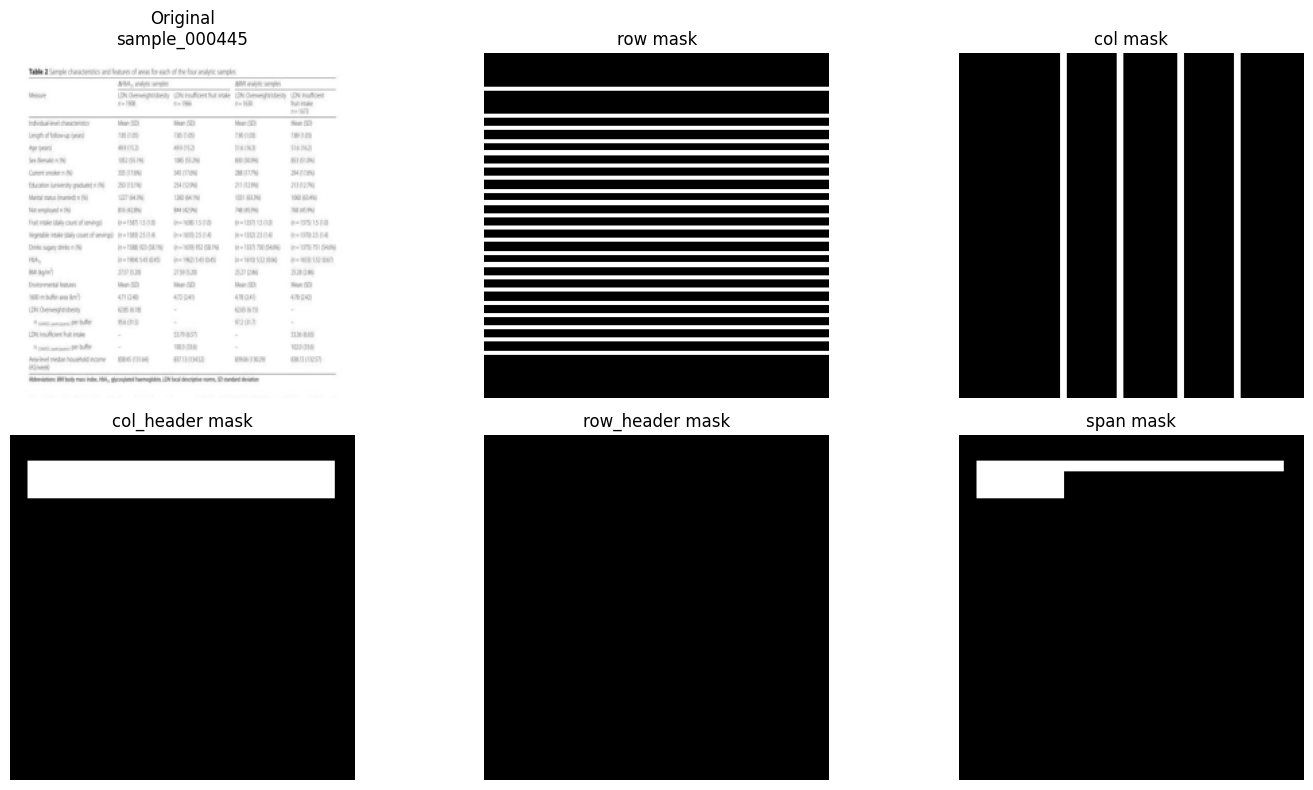


📊 Mask stats:
  row         : 25.8% white pixels
  col         : 7.8% white pixels
  col_header  : 9.7% white pixels
  row_header  : 0.0% white pixels
  span        : 4.8% white pixels


In [11]:
import xml.etree.ElementTree as ET
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import random

# Lấy 1 sample ngẫu nhiên
sample_ids = [f.stem for f in sorted(IMG_DIR.glob("*.png"))]
sid = random.choice(sample_ids)
print(f"Sample: {sid}")

# Load ảnh
img = Image.open(IMG_DIR / f"{sid}.png").convert("RGB")
print(f"Image size: {img.size}")

# Load và visualize 5 masks
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
mask_names = ["row", "col", "col_header", "row_header", "span"]

axes[0, 0].imshow(img)
axes[0, 0].set_title(f"Original\n{sid}")
axes[0, 0].axis("off")

for i, mtype in enumerate(mask_names):
    ax = axes[(i+1)//3, (i+1)%3]
    p  = mask_dir_lookup[sid] / f"{sid}_{mtype}.png"  # dùng lookup
    if p.exists():
        mask = Image.open(p).convert("L")
        ax.imshow(mask, cmap="gray")
        ax.set_title(f"{mtype} mask")
    else:
        ax.set_title(f"{mtype} — NOT FOUND")
    ax.axis("off")

plt.tight_layout()
plt.show()

# Thống kê masks
print("\n📊 Mask stats:")
for mtype in mask_names:
    p = mask_dir_lookup[sid] / f"{sid}_{mtype}.png"  # ← sửa MASK_DIR → mask_dir_lookup[sid]
    if p.exists():
        mask_arr = np.array(Image.open(p).convert("L"))
        white_pct = (mask_arr > 128).sum() / mask_arr.size * 100
        print(f"  {mtype:<12}: {white_pct:.1f}% white pixels")
    else:
        print(f"  {mtype:<12}: NOT FOUND")

In [12]:
import shutil
BASE = Path("/Users/macbookpro14m1pro/Desktop/RagTable/data/pubtabnet-1M")

# Tạo folder mới
NEW_MASK_DIR = BASE / "masks_dilated"

mask_dir_lookup = {
    f.stem.replace("_row", ""): NEW_MASK_DIR
    for f in NEW_MASK_DIR.glob("*_row.png")
}

all_ids = sorted(mask_dir_lookup.keys())
print(f"✅ mask_dir_lookup → {NEW_MASK_DIR}")
print(f"Total IDs in new lookup: {len(all_ids):,}")
print(f"Total masks: {len(list(NEW_MASK_DIR.glob('*.png'))):,}")

✅ mask_dir_lookup → /Users/macbookpro14m1pro/Desktop/RagTable/data/pubtabnet-1M/masks_dilated
Total IDs in new lookup: 30,000
Total masks: 149,826


In [42]:
import random

sample_check = random.sample(all_ids, 10)
for sid in sample_check:
    p = NEW_MASK_DIR / f"{sid}_col.png"
    if p.exists():
        mask = np.array(Image.open(p).convert("L"))
        pct = (mask > 128).mean() * 100
        print(f"{sid}: {pct:.1f}%")
    else:
        print(f"{sid}: col mask NOT FOUND")

sample_004517: 7.4%
sample_024544: 8.2%
sample_012594: 4.7%
sample_002414: 9.4%
sample_024243: 7.0%
sample_017518: 2.7%
sample_009869: 7.0%
sample_000538: 5.9%
sample_004251: 7.8%
sample_012254: 20.7%


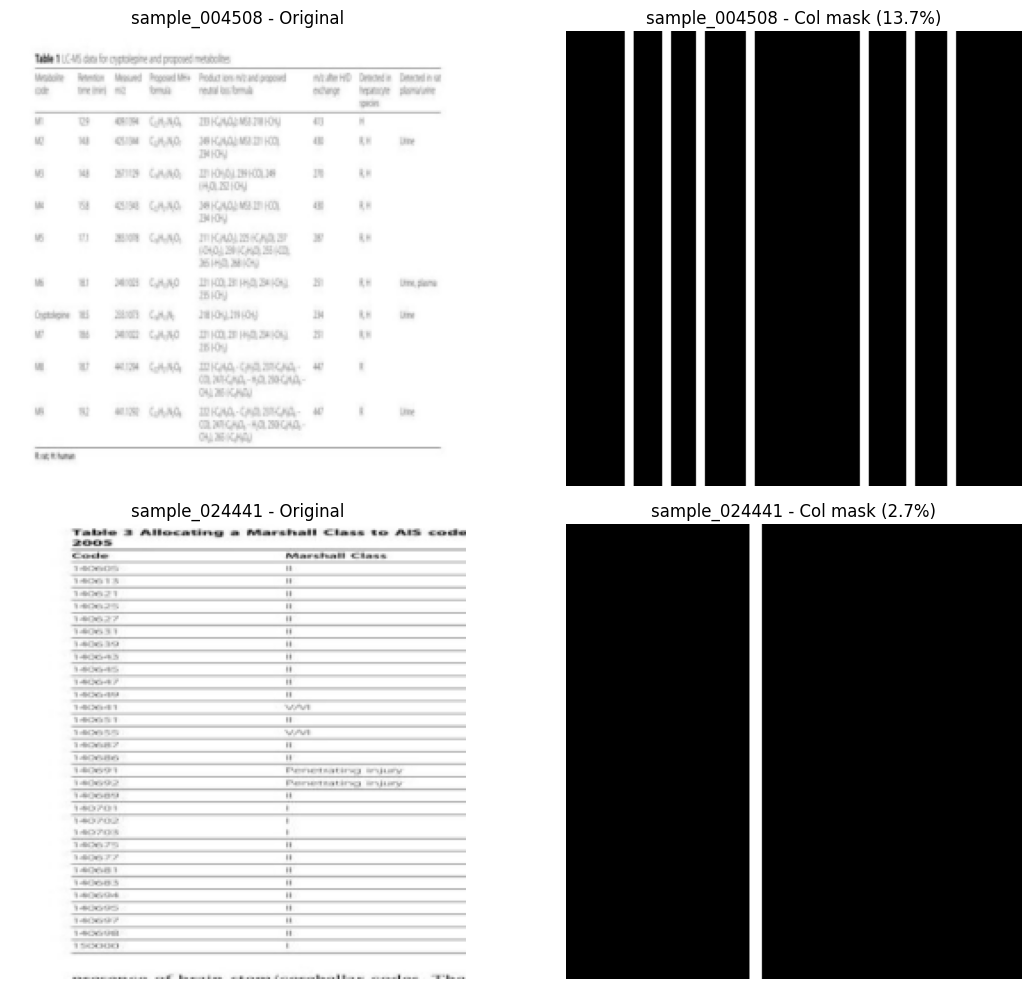

In [44]:
import matplotlib.pyplot as plt

suspicious = ["sample_004508", "sample_024441"]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for i, sid in enumerate(suspicious):
    # Ảnh gốc
    img = Image.open(IMG_DIR / f"{sid}.png").convert("RGB")
    axes[i, 0].imshow(img)
    axes[i, 0].set_title(f"{sid} - Original")
    axes[i, 0].axis("off")

    # Col mask sau dilate
    mask = Image.open(NEW_MASK_DIR / f"{sid}_col.png").convert("L")
    axes[i, 1].imshow(mask, cmap="gray")
    axes[i, 1].set_title(f"{sid} - Col mask ({(np.array(mask)>128).mean()*100:.1f}%)")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

In [13]:
# ── CELL 3: EfficientNet-B4 + UNet Decoder ───────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
import timm

class EfficientUNet(nn.Module):
    def __init__(self, out_ch=5, pretrained=True):
        super().__init__()

        # ── Encoder: EfficientNet-B4 ──────────────────
        self.encoder = timm.create_model(
            "efficientnet_b4",
            pretrained=pretrained,
            features_only=True,
            out_indices=(0, 1, 2, 3, 4),
        )
        # EfficientNet-B4 channel sizes: 24, 32, 56, 160, 448
        enc_chs = self.encoder.feature_info.channels()  # [24,32,56,160,448]

        # ── Bottleneck ────────────────────────────────
        self.bottleneck = nn.Sequential(
            nn.Conv2d(enc_chs[4], 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.Dropout2d(0.3),
            nn.Conv2d(256, 256, 3, padding=1, bias=False),
            nn.BatchNorm2d(256), nn.ReLU(inplace=True),
        )

        # ── Decoder blocks ────────────────────────────
        self.dec4 = self._dec_block(256 + enc_chs[3], 128)
        self.dec3 = self._dec_block(128 + enc_chs[2], 64)
        self.dec2 = self._dec_block(64  + enc_chs[1], 32)
        self.dec1 = self._dec_block(32  + enc_chs[0], 16)
        self.dec0 = self._dec_block(16, 16)  

        # ── Output ────────────────────────────────────
        self.out_conv = nn.Conv2d(16, out_ch, 1)

    def _dec_block(self, in_ch, out_ch):
        return nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )

    def forward(self, x):
        # Encoder
        feats = self.encoder(x)  # [s0,s1,s2,s3,s4]
        s0, s1, s2, s3, s4 = feats

        # Bottleneck
        b = self.bottleneck(s4)

        # Decoder + skip connections
        x = F.interpolate(b,  scale_factor=2, mode="bilinear", align_corners=False)
        x = self.dec4(torch.cat([x, s3], dim=1))

        x = F.interpolate(x,  scale_factor=2, mode="bilinear", align_corners=False)
        x = self.dec3(torch.cat([x, s2], dim=1))

        x = F.interpolate(x,  scale_factor=2, mode="bilinear", align_corners=False)
        x = self.dec2(torch.cat([x, s1], dim=1))

        x = F.interpolate(x,  scale_factor=2, mode="bilinear", align_corners=False)
        x = self.dec1(torch.cat([x, s0], dim=1))

        x = F.interpolate(x,  scale_factor=2, mode="bilinear", align_corners=False)
        x = self.dec0(x)

        return self.out_conv(x)


# ── Verify ────────────────────────────────────────────────
model = EfficientUNet(out_ch=5, pretrained=False).to(device)
dummy = torch.randn(2, 3, 384, 384).to(device)
with torch.no_grad():
    out = model(dummy)

total = sum(p.numel() for p in model.parameters())
print(f"Input:  {dummy.shape}")
print(f"Output: {out.shape}")
print(f"Params: {total/1e6:.1f}M")
print(f"Output size match: {out.shape[-2:] == torch.Size([384, 384])}")

Input:  torch.Size([2, 3, 384, 384])
Output: torch.Size([2, 5, 384, 384])
Params: 19.2M
Output size match: True


In [ ]:
# ── Before Cell 5 ──
import torch.nn as nn
import numpy as np

class DiceBCELoss(nn.Module):
    def __init__(self, bce_weight=0.3):
        super().__init__()
        self.bce_w = bce_weight
        self.bce   = nn.BCEWithLogitsLoss()
        self.channel_weights = torch.tensor([1.0, 4.0, 1.0, 2.0, 1.5])

    def forward(self, pred, target):
        weights = self.channel_weights.to(pred.device)
        total   = 0
        for i in range(pred.shape[1]):
            p = pred[:, i:i+1]
            t = target[:, i:i+1]
            bce      = nn.BCEWithLogitsLoss()(p, t)
            pred_sig = torch.sigmoid(p).reshape(-1)
            t_flat   = t.reshape(-1)
            inter    = (pred_sig * t_flat).sum()
            eps      = 1e-6
            dice     = 1 - (2*inter+eps)/(pred_sig.sum()+t_flat.sum()+eps)
            total   += weights[i] * (self.bce_w*bce + (1-self.bce_w)*dice)
        return total / pred.shape[1]

def compute_miou(pred_logits, target, threshold=0.5, thresholds=None):
    names = ["row","col","col_header","row_header","span"]
    ious  = {}
    for i, name in enumerate(names):
        thr  = thresholds[name] if thresholds else threshold
        pred = (torch.sigmoid(pred_logits[:, i]) > thr).float()
        p     = pred.reshape(-1)
        t     = target[:, i].reshape(-1)
        inter = (p*t).sum()
        union = (p+t-p*t).sum()
        ious[name] = (inter/union).item() if union >= 1 else float("nan")
    valid        = [v for v in ious.values() if not np.isnan(v)]
    ious["mean"] = np.mean(valid) if valid else 0.0
    return ious


scaler = torch.amp.GradScaler('cuda')

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total = 0
    for batch in loader:
        imgs, masks = batch["image"].to(device), batch["masks"].to(device)
        optimizer.zero_grad()
        with torch.amp.autocast('cuda'):
            loss = criterion(model(imgs), masks)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        total += loss.item()
    return total / len(loader)

def validate(model, loader, criterion, device, thresholds=None):
    model.eval()
    total    = 0
    all_ious = {n:[] for n in ["row","col","col_header","row_header","span"]}
    with torch.no_grad():
        for batch in loader:
            imgs, masks = batch["image"].to(device), batch["masks"].to(device)
            preds = model(imgs)
            total += criterion(preds, masks).item()
            for name, val in compute_miou(preds, masks, thresholds=thresholds).items():
                if name != "mean" and not np.isnan(val):
                    all_ious[name].append(val)
    avg_ious         = {n: np.mean(v) if v else 0.0 for n,v in all_ious.items()}
    avg_ious["mean"] = np.mean(list(avg_ious.values()))
    return total/len(loader), avg_ious

print("✅ Hàm đã định nghĩa xong!")

In [46]:
# ── Config ────────────────────────────────────────────────
IMG_SIZE   = 384
BATCH_SIZE = 8
MASK_TYPES = ["row", "col", "col_header", "row_header", "span"]
THRESHOLDS = {"row": 0.5, "col": 0.5, "col_header": 0.5,
              "row_header": 0.5, "span": 0.5}

OUTPUT_DIR = Path("/kaggle/working/test_predictions")
OUTPUT_DIR.mkdir(exist_ok=True)

# ── Dataset dùng lại đúng val_ids + mask_dir_lookup ───────
class ValTestDataset(Dataset):
    def __init__(self, sample_ids):
        self.sample_ids = sample_ids

    def __len__(self):
        return len(self.sample_ids)

    def __getitem__(self, idx):
        sid      = self.sample_ids[idx]
        mask_dir = mask_dir_lookup[sid]   # dùng đúng lookup cũ

        img = Image.open(IMG_DIR / f"{sid}.png").convert("RGB")
        img = TF.resize(img, (IMG_SIZE, IMG_SIZE),
                        interpolation=TF.InterpolationMode.BILINEAR)
        img_t = TF.to_tensor(img)

        masks = {}
        for mtype in MASK_TYPES:
            p = mask_dir / f"{sid}_{mtype}.png"
            if p.exists():
                m = Image.open(p).convert("L")
                m = TF.resize(m, (IMG_SIZE, IMG_SIZE),
                              interpolation=TF.InterpolationMode.NEAREST)
                masks[mtype] = (TF.to_tensor(m) > 0.5).float()
            else:
                masks[mtype] = torch.zeros(1, IMG_SIZE, IMG_SIZE)

        mask_t = torch.cat([masks[m] for m in MASK_TYPES], dim=0)
        return {"image": img_t, "masks": mask_t, "sid": sid}


# val_ids đã có sẵn từ lúc train, seed=42 nên reproducible
test_ds     = ValTestDataset(val_ids)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE,
                         shuffle=False, num_workers=2, pin_memory=True)

print(f"Test samples: {len(test_ds):,}")

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/working/test_predictions'

In [14]:
import torch
from pathlib import Path

# ── Load đúng best model ──────────────────────────────────
CKPT_SRC = Path("/Users/macbookpro14m1pro/Desktop/RagTable/data/table-seg-checkpoints-v2")
ckpt = torch.load(CKPT_SRC / "best_model.pt", map_location=device, weights_only=False)

model_eval = EfficientUNet(out_ch=5, pretrained=False).to(device)
model_eval.load_state_dict(ckpt["model"])
model_eval.eval()

print(f"✅ Loaded epoch={ckpt['epoch']} | best_miou={ckpt['best_miou']:.4f}")

✅ Loaded epoch=92 | best_miou=0.7962


In [34]:
# ── Inference + lưu mask + tính IoU ──────────────────────
import json

model.eval()
iou_accum = {name: [] for name in MASK_TYPES}

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Testing"):
        imgs  = batch["image"].to(device)
        masks = batch["masks"]
        sids  = batch["sid"]

        with torch.amp.autocast("cuda"):
            preds = torch.sigmoid(model_eval(imgs)).cpu() 

        for b in range(len(sids)):
            sid     = sids[b]
            sid_dir = OUTPUT_DIR / sid
            sid_dir.mkdir(exist_ok=True)

            for i, mtype in enumerate(MASK_TYPES):
                pred_bin = (preds[b, i] > THRESHOLDS[mtype]).numpy().astype(np.uint8)
                gt_bin   = (masks[b, i] > 0.5).numpy().astype(np.uint8)

                # Lưu mask PNG
                Image.fromarray(pred_bin * 255).save(
                    sid_dir / f"{sid}_{mtype}.png"
                )

                # Tính IoU
                inter = (pred_bin & gt_bin).sum()
                union = (pred_bin | gt_bin).sum()
                if union > 0:
                    iou_accum[mtype].append(inter / union)

# ── Kết quả ──────────────────────────────────────────────
print("\n" + "="*40)
print(f"{'Channel':<14} {'mIoU':>8}  {'N':>6}")
print("="*40)
all_means = []
for mtype in MASK_TYPES:
    vals = iou_accum[mtype]
    mean = np.mean(vals) if vals else 0.0
    all_means.append(mean)
    print(f"{mtype:<14} {mean:.4f}   {len(vals):>6}")
print("="*40)
print(f"{'MEAN':<14} {np.mean(all_means):.4f}")

# Lưu JSON
result = {m: float(np.mean(v)) for m, v in iou_accum.items()}
result["mean"]      = float(np.mean(all_means))
result["n_samples"] = len(test_ds)
with open("/kaggle/working/test_results.json", "w") as f:
    json.dump(result, f, indent=2)

print(f"\n✅ Xong! Masks → {OUTPUT_DIR}")
print(f"✅ Results → /kaggle/working/test_results.json")

Testing: 100%|██████████| 375/375 [01:13<00:00,  5.11it/s]



Channel            mIoU       N
row            0.7964     3000
col            0.7795     3000
col_header     0.8892     2841
row_header     0.7082      626
span           0.6665     1452
MEAN           0.7680

✅ Xong! Masks → /kaggle/working/test_predictions
✅ Results → /kaggle/working/test_results.json


In [15]:
import torch.nn.functional as F

def boundary_loss(pred, target, kernel_size=3):
    """Penalize lỗi tại boundary nhiều hơn"""
    pad = kernel_size // 2
    # Tính boundary của target bằng erosion
    eroded = -F.max_pool2d(-target, kernel_size, stride=1, padding=pad)
    boundary = target - eroded  # chỉ giữ lại viền

    bce = F.binary_cross_entropy_with_logits(pred, target, reduction='none')
    
    # Tăng weight tại vùng boundary
    weight = 1.0 + 5.0 * boundary
    return (bce * weight).mean()

class DiceFocalLoss(nn.Module):
    def __init__(self, focal_weight=0.4, boundary_weight=0.2, alpha=0.75, gamma=2.0):
        super().__init__()
        self.focal_w = focal_weight
        self.boundary_w = boundary_weight
        self.dice_w     = 1 - focal_weight - boundary_weight
        self.alpha = alpha
        self.gamma = gamma
        # Trọng số: [row, col, col_header, row_header, span]
        self.channel_weights = torch.tensor([2.0, 2.0, 1.0, 4.0, 6.0])

    def forward(self, pred, target):
        weights = self.channel_weights.to(pred.device)
        total = 0
        for i in range(pred.shape[1]):
            p = pred[:, i:i+1]
            t = target[:, i:i+1]
            
            # 1. Tính Focal Loss (xử lý viền mỏng)
            bce = F.binary_cross_entropy_with_logits(p, t, reduction='none')
            pt = torch.exp(-bce)
            focal_loss = (self.alpha * (1 - pt) ** self.gamma * bce).mean()
            
            # 2. Tính Dice Loss (xử lý IoU tổng thể)
            pred_sig = torch.sigmoid(p).reshape(-1)
            t_flat = t.reshape(-1)
            inter = (pred_sig * t_flat).sum()
            eps = 1e-6
            dice_loss = 1 - (2*inter+eps)/(pred_sig.sum()+t_flat.sum()+eps)
            b_loss = boundary_loss(p, t)
            
            # 3. Tổng hợp lại có nhân trọng số channel
            total += weights[i] * (
                self.focal_w * focal_loss +
                self.dice_w  * dice_loss  +
                self.boundary_w * b_loss
            )
            
        return total / pred.shape[1]
        
def compute_miou(pred_logits, target, threshold=0.5, thresholds=None):
    names = ["row","col","col_header","row_header","span"]
    ious  = {}
    for i, name in enumerate(names):
        thr  = thresholds[name] if thresholds else threshold
        pred = (torch.sigmoid(pred_logits[:, i]) > thr).float()
        p    = pred.reshape(-1)
        t    = target[:, i].reshape(-1)
        inter = (p*t).sum()
        union = (p+t-p*t).sum()
        ious[name] = (inter/union).item() if union >= 1 else float("nan")
    valid        = [v for v in ious.values() if not np.isnan(v)]
    ious["mean"] = np.mean(valid) if valid else 0.0
    return ious

def find_best_thresholds(model, loader, device):
    model.eval()
    all_preds = {i: [] for i in range(5)}
    all_masks  = {i: [] for i in range(5)}
    with torch.no_grad():
        for batch in loader:
            imgs, masks = batch["image"].to(device), batch["masks"].to(device)
            preds = torch.sigmoid(model(imgs))
            for i in range(5):
                all_preds[i].append(preds[:,i].cpu())
                all_masks[i].append(masks[:,i].cpu())
    names = ["row","col","col_header","row_header","span"]
    best_thresholds = {}
    for i, name in enumerate(names):
        p_all = torch.cat(all_preds[i]).reshape(-1).numpy()
        t_all = torch.cat(all_masks[i]).reshape(-1).numpy()
        best_iou, best_thr = 0, 0.5
        for thr in np.arange(0.3, 0.7, 0.05):
            p_bin = (p_all > thr).astype(float)
            inter = (p_bin * t_all).sum()
            union = (p_bin + t_all - p_bin * t_all).sum()
            iou   = inter / union if union > 0 else 0
            if iou > best_iou:
                best_iou, best_thr = iou, thr
        best_thresholds[name] = best_thr
        print(f"  {name}: best_thr={best_thr:.2f} → IoU={best_iou:.4f}")
    return best_thresholds

scaler = torch.amp.GradScaler('cuda')

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total = 0
    for batch in loader:
        imgs, masks = batch["image"].to(device), batch["masks"].to(device)
        optimizer.zero_grad()
        with torch.amp.autocast('cuda'):
            loss = criterion(model(imgs), masks)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        total += loss.item()
    return total / len(loader)

def validate(model, loader, criterion, device):
    model.eval()
    total    = 0
    all_ious = {n:[] for n in ["row","col","col_header","row_header","span"]}
    with torch.no_grad():
        for batch in loader:
            imgs, masks = batch["image"].to(device), batch["masks"].to(device)
            preds = model(imgs)
            total += criterion(preds, masks).item()
            for name, val in compute_miou(preds, masks).items():
                if name != "mean" and not np.isnan(val):
                    all_ious[name].append(val)
    avg_ious         = {n: np.mean(v) if v else 0.0 for n,v in all_ious.items()}
    avg_ious["mean"] = np.mean(list(avg_ious.values()))
    return total/len(loader), avg_ious

print("✅ Hàm đã định nghĩa xong!")

✅ Hàm đã định nghĩa xong!


/var/folders/pc/wtsv3z5s0j5bx006fg66b6mr0000gn/T/ipykernel_330/799224543.py:99: UserWarning: torch.cuda.amp.GradScaler is enabled, but CUDA is not available.  Disabling.
  scaler = torch.amp.GradScaler('cuda')


In [ ]:
import os, gc, time, shutil, subprocess, json
import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"
gc.collect()
torch.cuda.empty_cache()
torch.backends.cudnn.benchmark = True

# ── Config ────────────────────────────────────────────────
LR_FT     = 2e-6
EPOCHS_FT = 80    
patience  = 15    
CKPT_DIR   = Path("/kaggle/working/checkpoints_effb4_ft")
CKPT_DIR.mkdir(exist_ok=True)
BACKUP_DIR = Path("/kaggle/working/checkpoint_backup_ft")
BACKUP_DIR.mkdir(exist_ok=True)

scaler = torch.amp.GradScaler('cuda')

# ── DataLoader ────────────────────────────────────────────
train_loader = DataLoader(train_ds, batch_size=8, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=8, shuffle=False, num_workers=2, pin_memory=True)
print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

# ── Load best model ───────────────────────────────────────
CKPT_SRC = Path("/kaggle/input/table-seg-checkpoints-v2")
ckpt = torch.load(CKPT_SRC / "best_model.pt", map_location=device, weights_only=False)
model = EfficientUNet(out_ch=5, pretrained=False).to(device)
model.load_state_dict(ckpt["model"])
print(f"✅ Loaded epoch={ckpt['epoch']} | mIoU={ckpt['best_miou']:.4f}")

# ── Loss ──────────────────────────────────────────────────
criterion = DiceFocalLoss(focal_weight=0.4, boundary_weight=0.2, alpha=0.75, gamma=2.0).to(device)

# ── Optimizer ─────────────────────────────────────────────
optimizer = AdamW([
    {"params": model.encoder.parameters(),    "lr": LR_FT * 0.3},
    {"params": model.bottleneck.parameters(), "lr": LR_FT},
    {"params": model.dec4.parameters(),       "lr": LR_FT},
    {"params": model.dec3.parameters(),       "lr": LR_FT},
    {"params": model.dec2.parameters(),       "lr": LR_FT},
    {"params": model.dec1.parameters(),       "lr": LR_FT},
    {"params": model.dec0.parameters(),       "lr": LR_FT},
    {"params": model.out_conv.parameters(),   "lr": LR_FT},
], weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=15, T_mult=2, eta_min=1e-8
)

best_miou  = ckpt["best_miou"]
history_ft = ckpt["history"]
no_improve = 0 
START      = ckpt["epoch"] + 1
END        = START + 30

# ── Tạo dataset backup TRƯỚC khi train ───────────────────
meta_path = BACKUP_DIR / "dataset-metadata.json"
with open(meta_path, "w") as f:
    json.dump({
        "title": "table-seg-checkpoints-v2",
        "id": "tiinh123/table-seg-checkpoints-v2",
        "licenses": [{"name": "CC0-1.0"}]
    }, f)

# Copy checkpoint gốc vào backup rồi create dataset
check = subprocess.run([
    "kaggle", "datasets", "files",
    "tiinh123/table-seg-checkpoints-v2"
], capture_output=True, text=True)

if check.returncode == 0:
    print(f"✅ Dataset đã tồn tại, sẵn sàng backup")
else:
    shutil.copy2(CKPT_SRC / "best_model.pt", BACKUP_DIR / "best_model.pt")
    result = subprocess.run([
        "kaggle", "datasets", "create",
        "-p", str(BACKUP_DIR),
        "--dir-mode", "tar"
    ], capture_output=True, text=True)
    if "being created" in result.stdout:
        print(f"✅ Dataset created!")
    else:
        print(f"⚠️ {result.stdout[:100]}")

print(f"\nFine-tuning epoch {START} → {END-1} | lr={LR_FT}\n")

# ── Training loop ─────────────────────────────────────────
for epoch in range(START, END):
    t          = time.time()
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_ious = validate(model, val_loader, criterion, device)
    scheduler.step()
    miou = val_ious["mean"]

    history_ft["train_loss"].append(train_loss)
    history_ft["val_loss"].append(val_loss)
    history_ft["val_miou"].append(miou)

    print(f"Epoch {epoch:2d} | Train={train_loss:.4f} Val={val_loss:.4f} mIoU={miou:.4f} | {time.time()-t:.0f}s")

    if epoch % 5 == 0:
        print(f"  row={val_ious['row']:.3f} | col={val_ious['col']:.3f} | "
              f"hdr={val_ious['col_header']:.3f} | rhdr={val_ious['row_header']:.3f} | span={val_ious['span']:.3f}")

    # Save checkpoint local
    ckpt_new = {
        "epoch":      epoch,
        "model":      model.state_dict(),
        "optimizer":  optimizer.state_dict(),
        "scheduler":  scheduler.state_dict(),
        "history":    history_ft,
        "best_miou":  best_miou,
        "no_improve": no_improve,
    }
    torch.save(ckpt_new, CKPT_DIR / "last_checkpoint.pt")

    # Backup mỗi 5 epoch
    if epoch % 5 == 0:
        torch.save(ckpt_new, CKPT_DIR / f"checkpoint_epoch{epoch}.pt")
        shutil.copy2(CKPT_DIR / "last_checkpoint.pt", BACKUP_DIR / "last_checkpoint.pt")
        result = subprocess.run([
            "kaggle", "datasets", "version",
            "-p", str(BACKUP_DIR),
            "-m", f"epoch{epoch}-miou{miou:.4f}", 
            "--dir-mode", "tar"
        ], capture_output=True, text=True)

        if "Upload successful" in result.stderr or "successful" in result.stdout.lower():
            print(f"  💾 Saved + ☁️ Backed up epoch{epoch}")
        else:
            print(f"  ⚠️ Backup: {result.stdout[:80]}")

    # Best model
    if miou > best_miou:
        best_miou  = miou
        no_improve = 0
        torch.save(ckpt_new, CKPT_DIR / "best_model.pt")
        shutil.copy2(CKPT_DIR / "best_model.pt", BACKUP_DIR / "best_model.pt")

        result = subprocess.run([
            "kaggle", "datasets", "version",
            "-p", str(BACKUP_DIR),
            "-m", f"BEST-epoch{epoch}-miou{best_miou:.4f}",
            "--dir-mode", "tar"
        ], capture_output=True, text=True)

        if "Upload successful" in result.stderr or "successful" in result.stdout.lower():
            print(f"  ✅ Best saved + backed up (mIoU={best_miou:.4f})")
        else:
            print(f"  ⚠️ Backup status unknown: {result.stdout[:100]}")
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f"⛔ Early stopping epoch {epoch}")
            break

# ── Plot ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history_ft["train_loss"], label="Train")
axes[0].plot(history_ft["val_loss"],   label="Val")
axes[0].set_title("Fine-tune Loss"); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(history_ft["val_miou"], color="green", label="mIoU")
axes[1].axhline(0.80, color="red", linestyle="--", label="Target 0.80")
axes[1].set_title("Fine-tune mIoU"); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"\n✅ Fine-tune done! Best mIoU: {best_miou:.4f}")

Train batches: 3375 | Val batches: 375
✅ Loaded epoch=92 | mIoU=0.7962
✅ Dataset đã tồn tại, sẵn sàng backup

Fine-tuning epoch 93 → 122 | lr=2e-06

Epoch 93 | Train=0.2879 Val=0.7665 mIoU=0.7869 | 878s
Epoch 94 | Train=0.2877 Val=0.6298 mIoU=0.7849 | 776s
Epoch 95 | Train=0.2885 Val=0.7199 mIoU=0.7815 | 776s
  row=0.795 | col=0.770 | hdr=0.892 | rhdr=0.728 | span=0.723
  💾 Saved + ☁️ Backed up epoch95
Epoch 96 | Train=0.2850 Val=0.4032 mIoU=0.7882 | 775s
Epoch 97 | Train=0.2875 Val=0.3549 mIoU=0.7941 | 776s
Epoch 98 | Train=0.2862 Val=0.4154 mIoU=0.7860 | 776s
Epoch 99 | Train=0.2839 Val=0.9072 mIoU=0.7888 | 776s
Epoch 100 | Train=0.2895 Val=0.4168 mIoU=0.7876 | 776s
  row=0.797 | col=0.775 | hdr=0.896 | rhdr=0.740 | span=0.730
  💾 Saved + ☁️ Backed up epoch100
Epoch 101 | Train=0.2822 Val=0.3522 mIoU=0.7935 | 775s
Epoch 102 | Train=0.2859 Val=0.3561 mIoU=0.7917 | 779s
Epoch 103 | Train=0.2829 Val=0.3929 mIoU=0.7881 | 776s
Epoch 104 | Train=0.2883 Val=0.3548 mIoU=0.7927 | 775s


In [ ]:
# Tìm threshold tối ưu
thresholds = find_best_thresholds(model, val_loader, device)

# So sánh mIoU thường vs tối ưu
_, val_ious_opt = validate(model, val_loader, criterion, device)
print(f"mIoU thường (0.5): {val_ious_opt['mean']:.4f}")

model.eval()
with torch.no_grad():
    all_preds, all_masks_list = [], []
    for batch in val_loader:
        imgs, masks = batch["image"].to(device), batch["masks"].to(device)
        all_preds.append(model(imgs))
        all_masks_list.append(masks)
preds_cat = torch.cat(all_preds)
masks_cat  = torch.cat(all_masks_list)
opt_ious = compute_miou(preds_cat, masks_cat, thresholds=thresholds)
print(f"mIoU tối ưu threshold: {opt_ious['mean']:.4f}")

# Lưu thresholds vào best checkpoint
ckpt_final = torch.load(CKPT_DIR / "best_model.pt", map_location=device, weights_only=False)
ckpt_final["thresholds"] = thresholds
torch.save(ckpt_final, CKPT_DIR / "best_model.pt")
shutil.copy2(CKPT_DIR / "best_model.pt", BACKUP_DIR / "best_model.pt")
print(f"✅ Đã lưu thresholds vào best_model.pt")

In [16]:
import torch
from pathlib import Path

CKPT_SRC = Path("/Users/macbookpro14m1pro/Desktop/RagTable/data/table-seg-checkpoints-v2")

ckpt = torch.load(CKPT_SRC / "best_model.pt", map_location="cpu", weights_only=False)

print(f"Epoch: {ckpt['epoch']}")
print(f"best_miou: {ckpt['best_miou']:.4f}")
print(f"no_improve: {ckpt['no_improve']}")
print(ckpt.keys())

Epoch: 92
best_miou: 0.7962
no_improve: 8
dict_keys(['epoch', 'model', 'optimizer', 'scheduler', 'history', 'best_miou', 'no_improve'])


In [13]:
history_data = ckpt['history']

print("Kiểu dữ liệu của history:", type(history_data))

# 1. Nếu history là một danh sách các epoch (List of dicts)
if isinstance(history_data, list):
    for log in history_data:
        # Tìm đúng log của epoch 92
        if log.get('epoch', -1) == ckpt['epoch']: 
            print("\n🏆 CHI TIẾT TỪNG KÊNH CỦA EPOCH 92 🏆")
            for k, v in log.items():
                print(f"➤ {k:<15}: {v}")
            break

# 2. Nếu history là một từ điển chứa các mảng (Dict of lists)
elif isinstance(history_data, dict):
    print("\nCác thông số được lưu trong history:", history_data.keys())
    print("\n🏆 CHI TIẾT TỪNG KÊNH CỦA EPOCH 92 🏆")
    
    # Epoch 92 thường nằm ở vị trí index 91 (nếu lưu từ epoch 1)
    # hoặc index cuối cùng nếu lúc lưu best model bạn update history
    index_epoch = ckpt['epoch'] - 1 
    
    for key, values_list in history_data.items():
        if isinstance(values_list, list) and len(values_list) > index_epoch:
            val = values_list[index_epoch]
            # Format in cho đẹp nếu là số thập phân
            if isinstance(val, float):
                print(f"➤ {key:<15}: {val:.4f}")
            else:
                print(f"➤ {key:<15}: {val}")

Kiểu dữ liệu của history: <class 'dict'>

Các thông số được lưu trong history: dict_keys(['train_loss', 'val_loss', 'val_miou'])

🏆 CHI TIẾT TỪNG KÊNH CỦA EPOCH 92 🏆
➤ train_loss     : 0.2643
➤ val_loss       : 0.3186
➤ val_miou       : 0.7974


In [17]:
import numpy as np
import cv2
from PIL import Image
import torch
import torchvision.transforms.functional as TF
from dataclasses import dataclass
from typing import List

@dataclass
class Cell:
    row_idx: int
    col_idx: int
    x: int; y: int; w: int; h: int
    is_span: bool = False
    text: str = ""

In [39]:
def masks_to_cell_boxes(row_mask, col_mask, span_mask,
                         orig_w, orig_h, img_size=384) -> List[Cell]:
    """
    Step 2: Từ mask → tọa độ bbox chính xác từng ô
    Dùng contours thay vì projection
    """
    # ── Tìm đường kẻ ngang và dọc ──────────────────────────
    k_h = cv2.getStructuringElement(cv2.MORPH_RECT, (img_size//4, 1))
    k_v = cv2.getStructuringElement(cv2.MORPH_RECT, (1, img_size//4))
    k3  = np.ones((3, 3), np.uint8)

    # Tách đường ngang / dọc rõ ràng
    h_lines = cv2.morphologyEx(row_mask * 255, cv2.MORPH_OPEN,  k_h)
    v_lines = cv2.morphologyEx(col_mask * 255, cv2.MORPH_OPEN,  k_v)

    # Dilate nhẹ để nối đứt gãy
    h_lines = cv2.dilate(h_lines, k3, iterations=1)
    v_lines = cv2.dilate(v_lines, k3, iterations=1)

    # ── Tìm tọa độ đường kẻ ────────────────────────────────
    def mask_to_positions(proj, min_gap=6):
        """projection → list midpoint của mỗi đường kẻ"""
        norm    = proj / (proj.max() + 1e-6)
        is_line = norm > 0.03
        lines   = []
        in_line, start = False, 0
        for i, v in enumerate(is_line):
            if v and not in_line:
                in_line, start = True, i
            elif not v and in_line:
                in_line = False
                mid = (start + i) // 2
                # Bỏ nếu quá gần dòng trước
                if not lines or mid - lines[-1] >= min_gap:
                    lines.append(mid)
        return lines

    h_proj  = h_lines.sum(axis=1).astype(float)
    v_proj  = v_lines.sum(axis=0).astype(float)

    row_sep = [0] + mask_to_positions(h_proj) + [img_size]
    col_sep = [0] + mask_to_positions(v_proj) + [img_size]

    print(f"  → {len(row_sep)-1} rows, {len(col_sep)-1} cols")

    # ── Scale về ảnh gốc ───────────────────────────────────
    sx, sy = orig_w / img_size, orig_h / img_size

    cells = []
    for r in range(len(row_sep) - 1):
        for c in range(len(col_sep) - 1):
            y1, y2 = row_sep[r],  row_sep[r+1]
            x1, x2 = col_sep[c], col_sep[c+1]

            if (x2-x1) < 6 or (y2-y1) < 6:
                continue

            # Scale
            rx = int(x1 * sx); ry = int(y1 * sy)
            rw = int((x2-x1) * sx); rh = int((y2-y1) * sy)

            # Kiểm tra span: nếu vùng này có span_mask phủ > 50%
            span_region = span_mask[y1:y2, x1:x2]
            is_span = span_region.mean() > 0.5 if span_region.size > 0 else False

            cells.append(Cell(
                row_idx=r, col_idx=c,
                x=rx, y=ry, w=rw, h=rh,
                is_span=is_span
            ))

    return cells

In [35]:
from paddleocr import PaddleOCR

ocr = PaddleOCR(
    use_textline_orientation=False,   # TẮT auto-rotate
    use_doc_orientation_classify=False,
    use_doc_unwarping=False,          # TẮT unwarp
    lang="en"
)

Creating model: ('PP-OCRv5_server_det', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/Users/macbookpro14m1pro/.paddlex/official_models/PP-OCRv5_server_det`.
Creating model: ('en_PP-OCRv5_mobile_rec', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/Users/macbookpro14m1pro/.paddlex/official_models/en_PP-OCRv5_mobile_rec`.


In [40]:
import re

def clean_text(text, col_idx):
    text = text.strip()

    text = text.replace("~", "-")
    text = text.replace(",", ".")

    text = re.sub(r"\.\.+", ".", text)
    text = re.sub(r"[^\w\s\.\-\(\)<>=+*/%\[\]]", "", text)


    return text
    
def crop_and_ocr(image_pil, cells, ocr, upscale=3):
    img_np = np.array(image_pil.convert("RGB"))
    H, W   = img_np.shape[:2]

    for cell in cells:
        pad = int(min(cell.w, cell.h) * 0.05)
        x1 = max(0, cell.x - pad);  y1 = max(0, cell.y - pad)
        x2 = min(W, cell.x + cell.w + pad); y2 = min(H, cell.y + cell.h + pad)
        crop_rgb = img_np[y1:y2, x1:x2]

        if crop_rgb.size == 0:
            cell.text = ""; continue

        gray  = cv2.cvtColor(crop_rgb, cv2.COLOR_RGB2GRAY)
        scale = 4 if cell.row_idx == 0 else upscale
        gray  = cv2.resize(gray, None, fx=scale, fy=scale,
                           interpolation=cv2.INTER_CUBIC)
        gray  = cv2.normalize(gray, None, 0, 255, cv2.NORM_MINMAX)
        kernel = np.array([[0,-1,0],[-1,5,-1],[0,-1,0]])
        gray  = cv2.filter2D(gray, -1, kernel)
        img_input = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)

        # ── FIX 1: Dùng predict() thay ocr() ─────────────
        result = ocr.predict(img_input)

        # ── FIX 2: Parse đúng format mới ──────────────────
        text = ""
        if result:
            texts = []
            for page in result:
                # Format mới: page là dict có key 'rec_texts'
                if isinstance(page, dict) and "rec_texts" in page:
                    texts.extend(page["rec_texts"])
                # Fallback format cũ
                elif isinstance(page, list):
                    for line in page:
                        if isinstance(line, list) and len(line) >= 2:
                            t = line[1]
                            if isinstance(t, (list, tuple)):
                                texts.append(t[0])
                            elif isinstance(t, str):
                                texts.append(t)
            text = " ".join(t for t in texts if t)

        cell.text = clean_text(text, cell.col_idx)

    return cells

In [41]:
def cells_to_markdown(cells: List[Cell]) -> str:
    """
    Step 5: Ráp grid 2D → Markdown
    Sort theo (row_idx, col_idx) → không bao giờ nhảy cột
    """
    if not cells:
        return ""

    max_row = max(c.row_idx for c in cells) + 1
    max_col = max(c.col_idx for c in cells) + 1

    # Grid trống
    grid = [[""] * max_col for _ in range(max_row)]

    # Điền text vào đúng vị trí
    for cell in sorted(cells, key=lambda c: (c.row_idx, c.col_idx)):
        text_val = cell.text
        if cell.is_span and text_val != "":
            text_val = f"**{text_val}**" 
            
        grid[cell.row_idx][cell.col_idx] = text_val

    # Build markdown
    lines = []
    for r, row in enumerate(grid):
        lines.append("| " + " | ".join(row) + " |")
        if r == 0:
            lines.append("| " + " | ".join(["---"] * max_col) + " |")

    return "\n".join(lines)

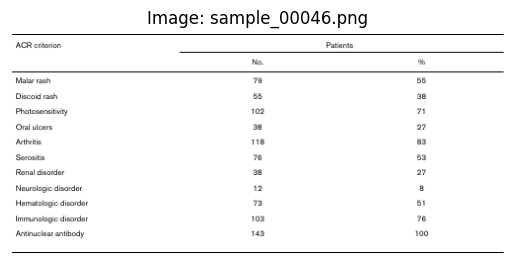

Ảnh gốc: 503×226px
  → 13 rows, 3 cols
Tổng cells: 39

=== Markdown Output ===
| ACRanterion | **Pati** | ents |
| --- | --- | --- |
|  | No. | % |
| Malar rash | 79 | 55 |
| Discoid rash | 65 | 38 |
| Photosensitivity | 102 | 71 |
| Orl ulcers | 38 | 27 |
| Arthritis | 118 | 83 |
| Serositis | 76 | 53 |
| Renal disorder | 39 | 27 |
| Neuralogio disorder | 12 | 8 |
| Hematologio disorder | 73 | 51 |
| Immunologio disorder | 103 | 76 |
| Antinuclear antibody | 143 | 100 |


In [42]:
import random
# ── Pipeline hoàn chỉnh ───────────────────────────────────
def image_to_markdown_v3(image_path, model, device, img_size=384):
    orig_img       = Image.open(image_path).convert("RGB")
    orig_w, orig_h = orig_img.size
    print(f"Ảnh gốc: {orig_w}×{orig_h}px")

    # 1. Model inference
    draft = TF.resize(orig_img, (img_size, img_size),
                      interpolation=TF.InterpolationMode.BILINEAR)
    img_t = TF.to_tensor(draft).unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        preds = torch.sigmoid(model(img_t)).squeeze(0).cpu().numpy()

    row_mask  = (preds[0] > 0.5).astype(np.uint8)
    col_mask  = (preds[1] > 0.5).astype(np.uint8)
    span_mask = (preds[4] > 0.5).astype(np.uint8)

    # 2. Mask → cell boxes
    cells = masks_to_cell_boxes(
        row_mask, col_mask, span_mask,
        orig_w, orig_h, img_size
    )
    print(f"Tổng cells: {len(cells)}")

    # 3+4. Crop từng ô → OCR
    cells = crop_and_ocr(orig_img, cells,ocr, upscale=2.5)

    # 5. → Markdown
    md = cells_to_markdown(cells)
    return md, cells

TEST_IMG_DIR = Path("/Users/macbookpro14m1pro/Desktop/RagTable/data/pubtabnet/images")
test_images = list(TEST_IMG_DIR.glob("*.png"))
if len(test_images) == 0:
    test_images = list(TEST_IMG_DIR.glob("*.jpg"))

# Chọn random ảnh
random_img_path = random.choice(test_images)
img = Image.open(random_img_path)
plt.imshow(img)
plt.axis("off")
plt.title(f"Image: {random_img_path.name}")
plt.show()

# ── Test ─────────────────────────────────────────────────
md, cells = image_to_markdown_v3(random_img_path, model_eval, device)
print("\n=== Markdown Output ===")
print(md)

In [43]:
import pandas as pd
from pathlib import Path
from tqdm import tqdm
import time
from rapidfuzz import fuzz
import re

# 1. CÁC HÀM ĐÁNH GIÁ (GIỮ NGUYÊN HOÀN TOÀN ĐỂ ĐẢM BẢO CÔNG BẰNG)
def markdown_to_grid(md_str):
    if not md_str: return []
    lines = [l.strip() for l in md_str.split('\n') if l.strip() and '|' in l and '---' not in l]
    grid = [list(map(str.strip, l.strip('|').split('|'))) for l in lines]
    return grid

def super_clean(text):
    if not text: return ""
    clean_text = re.sub(r'[^a-zA-Z0-9]', '', str(text)).lower()
    return clean_text

def calculate_cell_accuracy(md_pred, md_gt):
    grid_p = markdown_to_grid(md_pred)
    grid_g = markdown_to_grid(md_gt)
    
    if not grid_g: return 0.0
    if not grid_p: return 0.0 

    rows_g = len(grid_g)
    cols_g = len(grid_g[0])
    total_cells_gt = rows_g * cols_g
    
    match_count = 0
    
    for r in range(rows_g):
        for c in range(cols_g):
            try:
                p_raw = grid_p[r][c] if r < len(grid_p) and c < len(grid_p[0]) else ""
                g_raw = grid_g[r][c]
                
                p_text = super_clean(p_raw)
                g_text = super_clean(g_raw)
                
                if not p_text and not g_text:
                    match_count += 1
                elif p_text and g_text:
                    if p_text == g_text or fuzz.ratio(p_text, g_text) > 80:
                        match_count += 1
            except Exception:
                continue 
                
    return (match_count / total_cells_gt) * 100

# 2. HÀM DEBUG DÀNH CHO MODEL CUSTOM CỦA BẠN
def debug_top_5_custom_model(samples_list, gt_folder):
    print(f"{'='*20} DEBUG TOP 5 SAMPLES (U-NET PIPELINE) {'='*20}\n")
    
    for i in range(min(5, len(samples_list))):
        sample_path = samples_list[i]
        filename = sample_path.stem
        gt_file = Path(gt_folder) / f"{filename}.md"
        
        try:
            # ---> THAY ĐỔI CỐT LÕI: GỌI HÀM CỦA BẠN <---
            # Lưu ý: Tham số img_size = 384 theo đúng kiến trúc lúc train
            unet_md, _ = image_to_markdown_v3(str(sample_path), model_eval, device, img_size=384)
            if not unet_md: unet_md = "N/A"
            
            with open(gt_file, 'r', encoding='utf-8') as f:
                gt_md = f.read()
            
            print(f"--- SAMPLE: {filename} ---")
            print("\n[GROUND TRUTH (Bản chuẩn)]")
            print(gt_md[:300] + "...\n") 
            
            print("\n[U-NET PIPELINE PREDICTION]")
            print(unet_md[:300] + "...\n")
            
            acc = calculate_cell_accuracy(unet_md, gt_md)
            print(f"🎯 Accuracy mẫu này: {acc:.2f}%")
            print("-" * 50 + "\n")
            
        except Exception as e:
            print(f"Error at {filename}: {e}")